# 06 - Conjugate models for continuous data

**Goal.** Derive the conjugate models for measurements: exponential waiting times
with a gamma prior, a normal mean with known variance (by completing the square),
and the normal model with unknown mean and variance, whose marginal posterior for the
mean is a Student $t$. Each derivation is checked against a simulation.

## 1. Waiting times: the exponential-gamma model

**Model.** Waiting times $y_1,\dots,y_n$ between events that occur at an unknown rate
$\lambda$, with a gamma prior on the rate:
$$ y_i\mid\lambda\overset{\text{iid}}{\sim}\text{Exponential}(\lambda),\qquad \lambda\sim\text{Gamma}(\alpha,\beta). $$
The likelihood is $\prod_i\lambda e^{-\lambda y_i} = \lambda^n e^{-\lambda\sum y_i}$, so
$$ p(\lambda\mid y)\propto\lambda^n e^{-\lambda\sum y_i}\cdot\lambda^{\alpha-1}e^{-\beta\lambda}
   = \lambda^{\alpha+n-1}e^{-(\beta+\sum y_i)\lambda}, $$
$$ \boxed{\;\lambda\mid y\sim\text{Gamma}\Big(\alpha+n,\ \beta+\sum_i y_i\Big)\;} $$
Compare with the Poisson-gamma model of chapter 05: there the shape counted events
and the rate counted time periods; here the shape counts events (one per waiting
time) and the rate adds up the time waited. They are two views of the same process.

**Example.** A bus is scheduled "every 10 minutes", so we expect a rate of about
0.1 buses per minute, but we are not sure how reliable that is. A Gamma$(4, 40)$
prior has mean $0.1$ and is worth 4 observed waits totalling 40 minutes. We then
time 10 gaps between buses.

A useful subtlety: the **mean waiting time** is $1/\lambda$, and the posterior mean of
$1/\lambda$ is **not** one over the posterior mean of $\lambda$. For
$\lambda\sim$ Gamma$(a,b)$, $\mathbb E[1/\lambda] = b/(a-1)$ while
$1/\mathbb E[\lambda] = b/a$. Posterior quantities must be computed for the quantity you
care about, not transformed afterwards. With samples this is automatic: transform
each sample.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(6)

waits = np.array([12.5, 7.1, 15.8, 9.3, 21.0, 11.2, 8.4, 14.6, 10.9, 13.7])   # minutes between buses
a0, b0 = 4.0, 40.0
a1, b1 = a0 + len(waits), b0 + waits.sum()
post = stats.gamma(a=a1, scale=1 / b1)
print(f"posterior Gamma({a1:.0f}, {b1:.1f}); mean rate {post.mean():.4f} per minute")
print(f"mean wait: E[1/λ] = {b1 / (a1 - 1):.2f} min, but 1/E[λ] = {b1 / a1:.2f} min, sample mean {waits.mean():.2f} min")
lam = post.rvs(200_000, random_state=rng)
print(f"by sampling: E[1/λ] = {np.mean(1 / lam):.2f} min, 95% interval for the mean wait "
      f"({np.quantile(1 / lam, 0.025):.1f}, {np.quantile(1 / lam, 0.975):.1f}) min")

# Posterior predictive of the next wait: draw λ, then a wait given λ
next_wait = rng.exponential(1 / lam)
print(f"P(next wait > 20 min) = {(next_wait > 20).mean():.3f}   (plug-in exponential with 1/E[λ]: "
      f"{np.exp(-post.mean() * 20):.3f})")

posterior Gamma(14, 164.5); mean rate 0.0851 per minute
mean wait: E[1/λ] = 12.65 min, but 1/E[λ] = 11.75 min, sample mean 12.45 min
by sampling: E[1/λ] = 12.65 min, 95% interval for the mean wait (7.4, 21.5) min
P(next wait > 20 min) = 0.200   (plug-in exponential with 1/E[λ]: 0.182)


## 2. The normal mean with known variance

**Model.** Measurements $y_1,\dots,y_n$ of a quantity $\mu$ by an instrument with known
noise level $\sigma$, and a normal prior on $\mu$:
$$ y_i\mid\mu\overset{\text{iid}}{\sim}\text{Normal}(\mu,\sigma^2),\qquad \mu\sim\text{Normal}(m_0, s_0^2). $$

**One observation first.** Dropping constants, the log of likelihood times prior is
$$ -\frac{(y-\mu)^2}{2\sigma^2}-\frac{(\mu-m_0)^2}{2s_0^2}
   = -\frac12\left[\Big(\frac{1}{\sigma^2}+\frac{1}{s_0^2}\Big)\mu^2 - 2\Big(\frac{y}{\sigma^2}+\frac{m_0}{s_0^2}\Big)\mu\right] + \text{const}. $$
It is a quadratic in $\mu$ with a negative leading coefficient, so the posterior is
normal. To read off its mean and variance, **complete the square**: for any $a>0$,
$a\mu^2 - 2b\mu = a(\mu - b/a)^2 - b^2/a$, and the last term is a constant. With
$a = 1/\sigma^2 + 1/s_0^2$ and $b = y/\sigma^2 + m_0/s_0^2$, the posterior is
Normal$(b/a,\ 1/a)$.

**Precision** (one over variance) makes this clean: $a$ is the prior precision
$1/s_0^2$ plus the precision $1/\sigma^2$ of one measurement, and the posterior mean
$b/a$ weights $y$ and $m_0$ by their precisions.

**$n$ observations.** The data enter only through $\bar y$, whose distribution is
Normal$(\mu, \sigma^2/n)$, so replace $y$ by $\bar y$ and $\sigma^2$ by $\sigma^2/n$:
$$ \boxed{\;\mu\mid y\sim\text{Normal}(m_1, s_1^2),\qquad
   \frac{1}{s_1^2} = \frac{1}{s_0^2}+\frac{n}{\sigma^2},\qquad
   m_1 = s_1^2\Big(\frac{m_0}{s_0^2}+\frac{n\bar y}{\sigma^2}\Big)\;} $$
**Precisions add**, and the posterior mean is the **precision-weighted average** of
the prior mean and the sample mean. The prior is worth $\sigma^2/s_0^2$ observations.
With a very vague prior ($s_0\to\infty$) the posterior becomes Normal$(\bar y,
\sigma^2/n)$, whose 95% interval $\bar y\pm1.96\,\sigma/\sqrt n$ is numerically the
classical confidence interval.

The **posterior predictive** for a new measurement is Normal$(m_1,\ s_1^2+\sigma^2)$:
the variances add because a new measurement is $\mu$ plus independent noise.

**Example.** A lab weighs a sample on a scale whose readings have standard deviation
$\sigma = 0.30$ g. The supplier states the mass as $10.0 \pm 0.5$ g, which we take as a
Normal$(10.0, 0.5^2)$ prior. Five readings are taken.

sample mean 10.382 g; prior is worth 0.36 readings
posterior Normal(10.356, 0.130^2);  95% credible interval (10.102, 10.610) g
next reading: predictive Normal(10.356, 0.327^2)
grid check: mean 10.356, sd 0.130


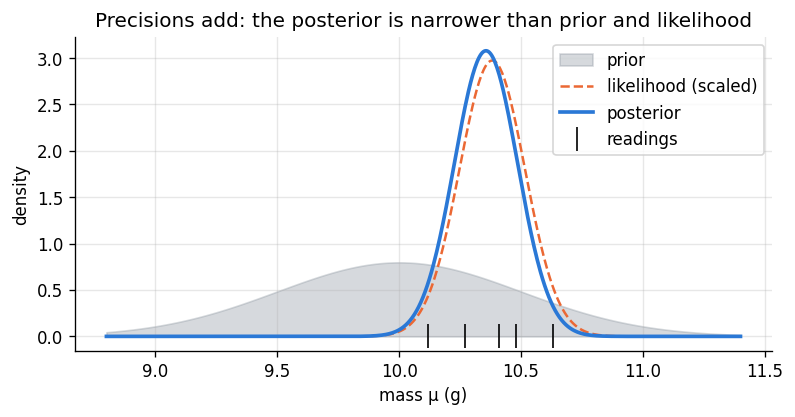

In [2]:
sigma = 0.30
m0, s0 = 10.0, 0.5
readings = np.array([10.41, 10.12, 10.63, 10.27, 10.48])
n, ybar = len(readings), readings.mean()

prec1 = 1 / s0**2 + n / sigma**2
s1 = np.sqrt(1 / prec1)
m1 = (m0 / s0**2 + n * ybar / sigma**2) / prec1
print(f"sample mean {ybar:.3f} g; prior is worth {sigma**2 / s0**2:.2f} readings")
print(f"posterior Normal({m1:.3f}, {s1:.3f}^2);  95% credible interval ({m1 - 1.96 * s1:.3f}, {m1 + 1.96 * s1:.3f}) g")
print(f"next reading: predictive Normal({m1:.3f}, {np.sqrt(s1**2 + sigma**2):.3f}^2)")

# Check against a brute-force grid posterior
mu = np.linspace(8, 12, 40001); dmu = mu[1] - mu[0]
logpost = stats.norm.logpdf(mu, m0, s0) + stats.norm.logpdf(readings[:, None], mu, sigma).sum(axis=0)
grid = np.exp(logpost - logpost.max()); grid /= grid.sum() * dmu
print(f"grid check: mean {np.sum(mu * grid) * dmu:.3f}, sd {np.sqrt(np.sum((mu - m1)**2 * grid) * dmu):.3f}")

x = np.linspace(8.8, 11.4, 600)
plt.fill_between(x, stats.norm.pdf(x, m0, s0), color=PRIOR, alpha=0.35, label="prior")
plt.plot(x, stats.norm.pdf(x, ybar, sigma / np.sqrt(n)), color=LIK, lw=1.5, ls="--", label="likelihood (scaled)")
plt.plot(x, stats.norm.pdf(x, m1, s1), color=POST, lw=2.2, label="posterior")
plt.plot(readings, np.zeros(n), "|", color="k", ms=14, label="readings")
plt.xlabel("mass μ (g)"); plt.ylabel("density"); plt.legend()
plt.title("Precisions add: the posterior is narrower than prior and likelihood")
plt.show()

## 3. Unknown mean and unknown variance

Usually $\sigma^2$ is unknown too. We need a joint prior on $(\mu,\sigma^2)$. The
conjugate choice is the **normal-inverse-gamma** prior [1, 3]:
$$ \sigma^2\sim\text{InvGamma}(\alpha,\beta),\qquad \mu\mid\sigma^2\sim\text{Normal}\Big(m,\ \frac{\sigma^2}{w}\Big). $$
Two new pieces:

- The **inverse-gamma** distribution: $\sigma^2\sim$ InvGamma$(\alpha,\beta)$ means
  $1/\sigma^2\sim$ Gamma$(\alpha,\beta)$. Its density is
  $\frac{\beta^\alpha}{\Gamma(\alpha)}(\sigma^2)^{-\alpha-1}e^{-\beta/\sigma^2}$ and its mean
  is $\beta/(\alpha-1)$ for $\alpha>1$. To sample it, sample a gamma and take one over it.
- The prior on $\mu$ is scaled by $\sigma^2$: $w$ is the number of observations the
  prior on $\mu$ is worth, measured in units of the (unknown) noise.

**Posterior.** The same completing-the-square argument, done for both parameters
together, gives
$$ \sigma^2\mid y\sim\text{InvGamma}\Big(\alpha+\frac n2,\ \ \beta+\frac{(n-1)s^2}{2}+\frac{wn}{2(w+n)}(\bar y-m)^2\Big), $$
$$ \mu\mid\sigma^2,y\sim\text{Normal}\Big(\frac{n\bar y+wm}{n+w},\ \frac{\sigma^2}{n+w}\Big), $$
where $s^2 = \sum_i(y_i-\bar y)^2/(n-1)$ is the sample variance. The rate of the
inverse-gamma collects the spread within the data and a penalty for disagreement
between $\bar y$ and the prior guess $m$.

**The marginal posterior of $\mu$.** We rarely care about $\sigma^2$ itself.
Integrating it out of the joint posterior gives a **Student $t$** with $2\alpha+n$
degrees of freedom, location $m^* = (n\bar y+wm)/(n+w)$ and scale
$$ \gamma = \sqrt{\frac{\beta'}{(n+w)\,\alpha'}},\qquad \alpha' = \alpha+\tfrac n2,\quad \beta' = \text{the posterior rate above}. $$
Heavier tails than a normal is exactly what honest uncertainty about $\sigma$ should
produce. It is the Bayesian counterpart of the familiar $t$ confidence interval.

**Sampling the joint posterior exactly** needs no special algorithm: draw
$\sigma^2$ from its inverse-gamma, then draw $\mu$ from its normal given that
$\sigma^2$. Each pair is an exact, independent draw from the joint posterior. This
"sample the marginal, then the conditional" pattern (**composition sampling**)
returns in chapter 08.

**Example.** The battery life (hours) of 12 phones of a new model is measured. We use
a weak prior: $m = 10$ hours, $w = 1$ (worth one phone), and $\alpha = 2$, $\beta = 1$ for
the variance (mean of $\sigma^2$ equal to 1).

n = 12, sample mean 10.308, sample sd 0.654
σ² | y ~ InvGamma(8.0, 3.398),  posterior mean of σ² = 0.485
μ | y ~ t_16(location 10.285, scale 0.1808);  95% credible interval (9.901, 10.668)
classical 95% t confidence interval  (9.893, 10.724)
sampled μ: mean 10.285, 95% interval (9.902, 10.668)


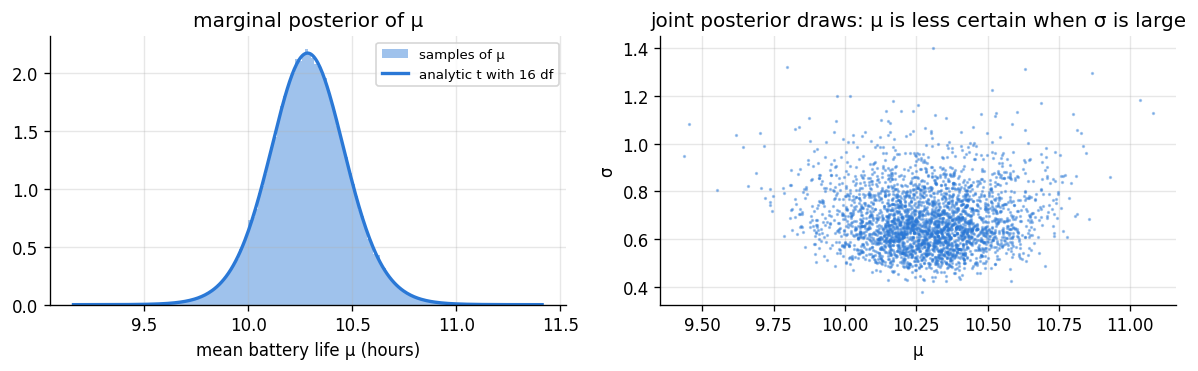

In [3]:
life = np.array([9.8, 10.4, 11.1, 9.2, 10.9, 10.1, 9.6, 10.7, 11.4, 10.0, 9.9, 10.6])
n, ybar, s2 = len(life), life.mean(), life.var(ddof=1)
m, w, alpha, beta = 10.0, 1.0, 2.0, 1.0

alpha1 = alpha + n / 2
beta1 = beta + (n - 1) * s2 / 2 + w * n / (2 * (w + n)) * (ybar - m) ** 2
m_star = (n * ybar + w * m) / (n + w)
gamma = np.sqrt(beta1 / ((n + w) * alpha1))
nu = 2 * alpha + n
t_post = stats.t(df=nu, loc=m_star, scale=gamma)
print(f"n = {n}, sample mean {ybar:.3f}, sample sd {np.sqrt(s2):.3f}")
print(f"σ² | y ~ InvGamma({alpha1:.1f}, {beta1:.3f}),  posterior mean of σ² = {beta1 / (alpha1 - 1):.3f}")
print(f"μ | y ~ t_{nu:.0f}(location {m_star:.3f}, scale {gamma:.4f});  95% credible interval "
      f"({t_post.ppf(0.025):.3f}, {t_post.ppf(0.975):.3f})")
tc = stats.t.ppf(0.975, n - 1) * np.sqrt(s2 / n)
print(f"classical 95% t confidence interval  ({ybar - tc:.3f}, {ybar + tc:.3f})")

# Composition sampling: σ² from its inverse-gamma, then μ given σ²
sig2 = 1 / rng.gamma(alpha1, 1 / beta1, size=200_000)
mu = rng.normal(m_star, np.sqrt(sig2 / (n + w)))
print(f"sampled μ: mean {mu.mean():.3f}, 95% interval ({np.quantile(mu, 0.025):.3f}, {np.quantile(mu, 0.975):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(mu, bins=150, density=True, color=POST, alpha=0.45, label="samples of μ")
g = np.linspace(mu.min(), mu.max(), 400)
ax[0].plot(g, t_post.pdf(g), color=POST, lw=2, label=f"analytic t with {nu:.0f} df")
ax[0].set_xlabel("mean battery life μ (hours)"); ax[0].legend(fontsize=8)
ax[0].set_title("marginal posterior of μ")
ax[1].plot(mu[:3000], np.sqrt(sig2[:3000]), ".", ms=2, color=POST, alpha=0.4)
ax[1].set_xlabel("μ"); ax[1].set_ylabel("σ"); ax[1].set_title("joint posterior draws: μ is less certain when σ is large")
plt.tight_layout(); plt.show()

The right panel shows why the marginal of $\mu$ has heavy tails: the posterior of
$\mu$ is wide in exactly the draws where $\sigma$ is large, and averaging normals of
different widths produces a $t$.

## 4. A summary of the conjugate models so far

| data model | parameter | conjugate prior | posterior |
|---|---|---|---|
| Binomial$(n,\theta)$ | $\theta$ | Beta$(\alpha,\beta)$ | Beta$(\alpha+y,\ \beta+n-y)$ |
| Poisson$(\lambda)$, $n$ counts | $\lambda$ | Gamma$(\alpha,\beta)$ | Gamma$(\alpha+\sum y_i,\ \beta+n)$ |
| Exponential$(\lambda)$, $n$ waits | $\lambda$ | Gamma$(\alpha,\beta)$ | Gamma$(\alpha+n,\ \beta+\sum y_i)$ |
| Normal$(\mu,\sigma^2)$, $\sigma$ known | $\mu$ | Normal$(m_0,s_0^2)$ | Normal, precisions add |
| Normal$(\mu,\sigma^2)$ | $(\mu,\sigma^2)$ | Normal-InvGamma | Normal-InvGamma; $\mu$ marginally $t$ |

All of these data models are **exponential families**, and every exponential family
has a conjugate prior of the same "add the sufficient statistics to the
hyperparameters" form [2].

### Exercises

1. For the bus example, what is the posterior probability that the true mean gap is
   more than 12 minutes? Compute it both from the gamma posterior of $\lambda$ and from
   the samples of $1/\lambda$.
2. Prove $\mathbb E[1/\lambda] = \beta/(\alpha-1)$ for $\lambda\sim$ Gamma$(\alpha,\beta)$.
3. In the weighing example, how many readings would be needed for the posterior standard
   deviation to fall below 0.05 g? Does the answer depend on the readings' values?
4. Show that updating the normal-mean model with the readings one at a time gives the
   same posterior as the batch formula (use the precision form).
5. For the battery data, shrink the prior on $\mu$ towards $m=12$ with $w=1$ and with
   $w=20$. Which conclusion changes, and why does $w$ matter more than $m$?
6. Derive the posterior for $\sigma^2$ with a **known** mean $\mu$ and an
   InvGamma$(\alpha,\beta)$ prior.

## References

1. P. D. Hoff. *A First Course in Bayesian Statistical Methods.* Springer, 2009. (Chapter 5.)
2. P. Diaconis, D. Ylvisaker. *Conjugate priors for exponential families.* The Annals of Statistics, 7(2):269-281, 1979. doi:10.1214/aos/1176344611
3. A. Gelman et al. *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013. (Chapter 3.)
4. G. E. P. Box, G. C. Tiao. *Bayesian Inference in Statistical Analysis.* Addison-Wesley, 1973.
5. K. P. Murphy. *Conjugate Bayesian analysis of the Gaussian distribution.* Technical note, 2007.
6. W. M. Bolstad. *Introduction to Bayesian Statistics.* Wiley, 2004.